<a href="https://colab.research.google.com/github/positivefunctionIN/Medical_Imaging_using_CNN/blob/main/Model1_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle -q

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Add, Multiply, Concatenate, Activation, Lambda
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_5b435f7615b49cc51191f5ab984c36d2"

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

data_path = "/content/chest_xray_data/chest_xray"

IMG_SIZE = 224
BATCH_SIZE = 32
CLASS_NAMES = ['Normal', 'Pneumonia']
NUM_CLASSES = 1

TensorFlow version: 2.20.0
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:14<00:00, 168MB/s] 



In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)
val_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    f"{data_path}/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\n✅ Train samples: {train_generator.samples}")
print(f"✅ Val samples: {val_generator.samples}")
print(f"✅ Test samples: {test_generator.samples}")
print(f"✅ Class mapping: {train_generator.class_indices}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

✅ Train samples: 4173
✅ Val samples: 1043
✅ Test samples: 624
✅ Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
print("\n" + "="*60)
print("🔵 MODEL 1: Custom CNN ")
print("="*60)

def build_custom_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='sigmoid')
    ])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Custom CNN built")
custom_cnn.summary()

custom_history = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

custom_test_loss, custom_test_acc = custom_cnn.evaluate(test_generator, verbose=0)
print(f"\n📊 Custom CNN Test Accuracy: {custom_test_acc:.2%}")


🔵 MODEL 1: Custom CNN 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Custom CNN built


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,263,809 (73.49 MB)

 Trainable params: 19,263,809 (73.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 123s 868ms/step - accuracy: 0.7853 - loss: 0.4658 - val_accuracy: 0.8849 - val_loss: 0.2614
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 141s 920ms/step - accuracy: 0.8847 - loss: 0.2696 - val_accuracy: 0.8869 - val_loss: 0.2450
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 924ms/step - accuracy: 0.9118 - loss: 0.2306 - val_accuracy: 0.9089 - val_loss: 0.2079
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9216 - loss: 0.1999 - val_accuracy: 0.9108 - val_loss: 0.1963
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 119s 911ms/step - accuracy: 0.9269 - loss: 0.1856 - val_accuracy: 0.9185 - val_loss: 0.2054
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 922ms/step - accuracy: 0.9307 - loss: 0.1709 - val_accuracy: 0.9185 - val_loss: 0.2113
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 923ms/step - accuracy: 0.9384 - loss: 0.1738 - val_accuracy: 0.9434 - val_loss: 0.1508
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9444 - loss:

In [ ]:
for i, layer in enumerate(custom_cnn.layers):
    print(i, layer.name, layer.output.shape)

In [ ]:
last_conv_layer_name = "conv2d_3"

In [ ]:
dummy = np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
_ = custom_cnn.predict(dummy, verbose=0)

In [ ]:
print(custom_cnn.input_shape)
print(custom_cnn.output_shape)
print(custom_cnn.get_layer("conv2d_3"))

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    last_conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.Model(
      inputs=[model.input],
      outputs=[
          model.get_layer(last_conv_layer_name).output,
          model.output
      ]
   )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()

    return heatmap.numpy()

In [ ]:
test_generator.reset()

images, labels = next(test_generator)

img = images[0]
label = labels[0]

img_array = np.expand_dims(img, axis=0)

pred = custom_cnn.predict(img_array, verbose=0)[0][0]

pred_class = "PNEUMONIA" if pred > 0.5 else "NORMAL"
actual_class = "PNEUMONIA" if label == 1 else "NORMAL"

print("Actual:", actual_class)
print("Predicted:", pred_class)
print("Confidence:", pred)

 UPLOAD A CHEST X-RAY IMAGE


Saving shutterstock_786937069.webp to shutterstock_786937069 (1).webp

Uploaded: shutterstock_786937069 (1).webp

 Prediction: PNEUMONIA (92.8% confidence)


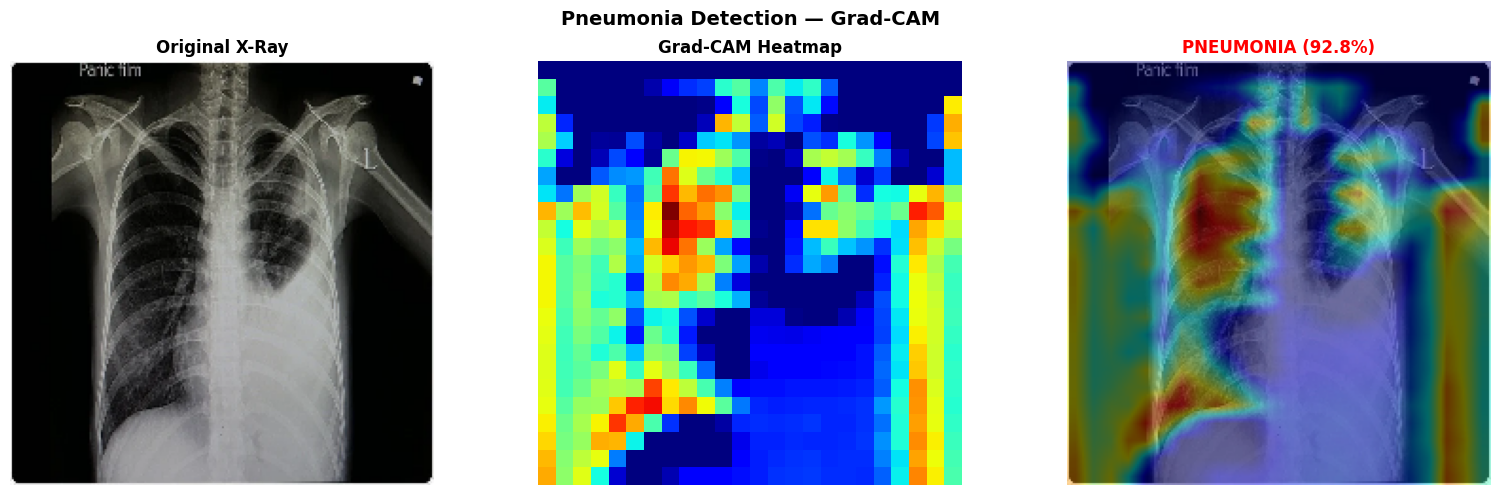


Red/yellow = regions the model focused on


(np.float32(0.9283273),
 array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [4.55949128e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 4.11292389e-02, 1.09327130e-01,
         1.70720935e-01, 1.90255418e-01, 3.98979843e-01, 4.50495601e-01,
         2.54935533e-01, 4.44841087e-01, 3.55506361e-01, 4.06521678e-01,
         2.16183886e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [3.58421504e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    last_conv_layer = model.get_layer(last_conv_layer_name)

    @tf.function
    def compute_gradcam(inputs):
        with tf.GradientTape() as tape:
            x = inputs
            conv_output = None
            for layer in model.layers:
                x = layer(x)
                if layer == last_conv_layer:
                    tape.watch(x)
                    conv_output = x
            loss = x[0][0]

        grads = tape.gradient(loss, conv_output)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_output = conv_output[0]
        heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)
        heatmap = tf.maximum(heatmap, 0)
        heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()

        return heatmap

    return compute_gradcam(img_array).numpy()


def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    if img.max() <= 1.0:
        img = np.uint8(255 * img)

    return cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)


def upload_and_predict():
    print(" UPLOAD A CHEST X-RAY IMAGE")

    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return

    filename = list(uploaded.keys())[0]
    print(f"\nUploaded: {filename}")

    img = tf.keras.preprocessing.image.load_img(
        filename, target_size=(IMG_SIZE, IMG_SIZE)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    prediction = custom_cnn.predict(img_batch, verbose=0)[0][0]
    pred_class = "PNEUMONIA" if prediction > 0.5 else "NORMAL"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"\n Prediction: {pred_class} ({confidence:.1%} confidence)")

    heatmap = make_gradcam_heatmap(img_batch, custom_cnn, "conv2d_3")
    overlay = overlay_heatmap(img_array, heatmap, alpha=0.4)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(img_array)
    axes[0].set_title("Original X-Ray", fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap", fontweight='bold')
    axes[1].axis('off')

    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    axes[2].imshow(overlay_rgb)
    axes[2].set_title(
        f"{pred_class} ({confidence:.1%})",
        fontweight='bold',
        color='red' if pred_class == "PNEUMONIA" else 'green'
    )
    axes[2].axis('off')

    plt.suptitle("Pneumonia Detection — Grad-CAM", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nRed/yellow = regions the model focused on")
    return prediction, heatmap


upload_and_predict()

In [ ]:
from google.colab import files
custom_cnn.save("pneumonia_model.h5")
files.download("pneumonia_model.h5")